<a href="https://colab.research.google.com/github/mundundan-star/online-retail-customer-analytics/blob/main/4_0_Retention_and_Churn_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine, inspect, text
from google.colab import userdata

engine = create_engine(userdata.get("NEON_DATABASE_URL"))

query = """
WITH data AS(
SELECT "CustomerID",
    EXTRACT(MONTH FROM "InvoiceDate") AS "TxnMonth",
    EXTRACT(YEAR FROM "InvoiceDate") AS "TxnYear",
    "CohortMonth",
    "CohortMonth1",
    "CohortYear",
    "Revenue"
FROM v_clean_sales_analytics
LEFT JOIN (SELECT "CustomerID",
          TO_CHAR(MIN("InvoiceDate"), 'YYYY-MM') AS "CohortMonth",
          EXTRACT(MONTH FROM MIN("InvoiceDate")) AS "CohortMonth1",
          EXTRACT(YEAR FROM MIN("InvoiceDate")) AS "CohortYear"
          FROM  v_clean_sales_analytics
          GROUP BY "CustomerID")
USING("CustomerID")
WHERE "InvoiceDate" <= '2011-08-31'),

month_number AS(
SELECT "CustomerID",
    "CohortMonth",
    "CohortMonth1",
    (("TxnYear" - "CohortYear") * 12) + ("TxnMonth" - "CohortMonth1") AS "MonthNumber",
    "Revenue"
FROM data)

SELECT "CohortMonth",
        "MonthNumber",
        COUNT(DISTINCT "CustomerID") AS "NoCustomers"
FROM month_number
GROUP BY "CohortMonth", "MonthNumber"
"""

df = pd.read_sql(text(query), con = engine)

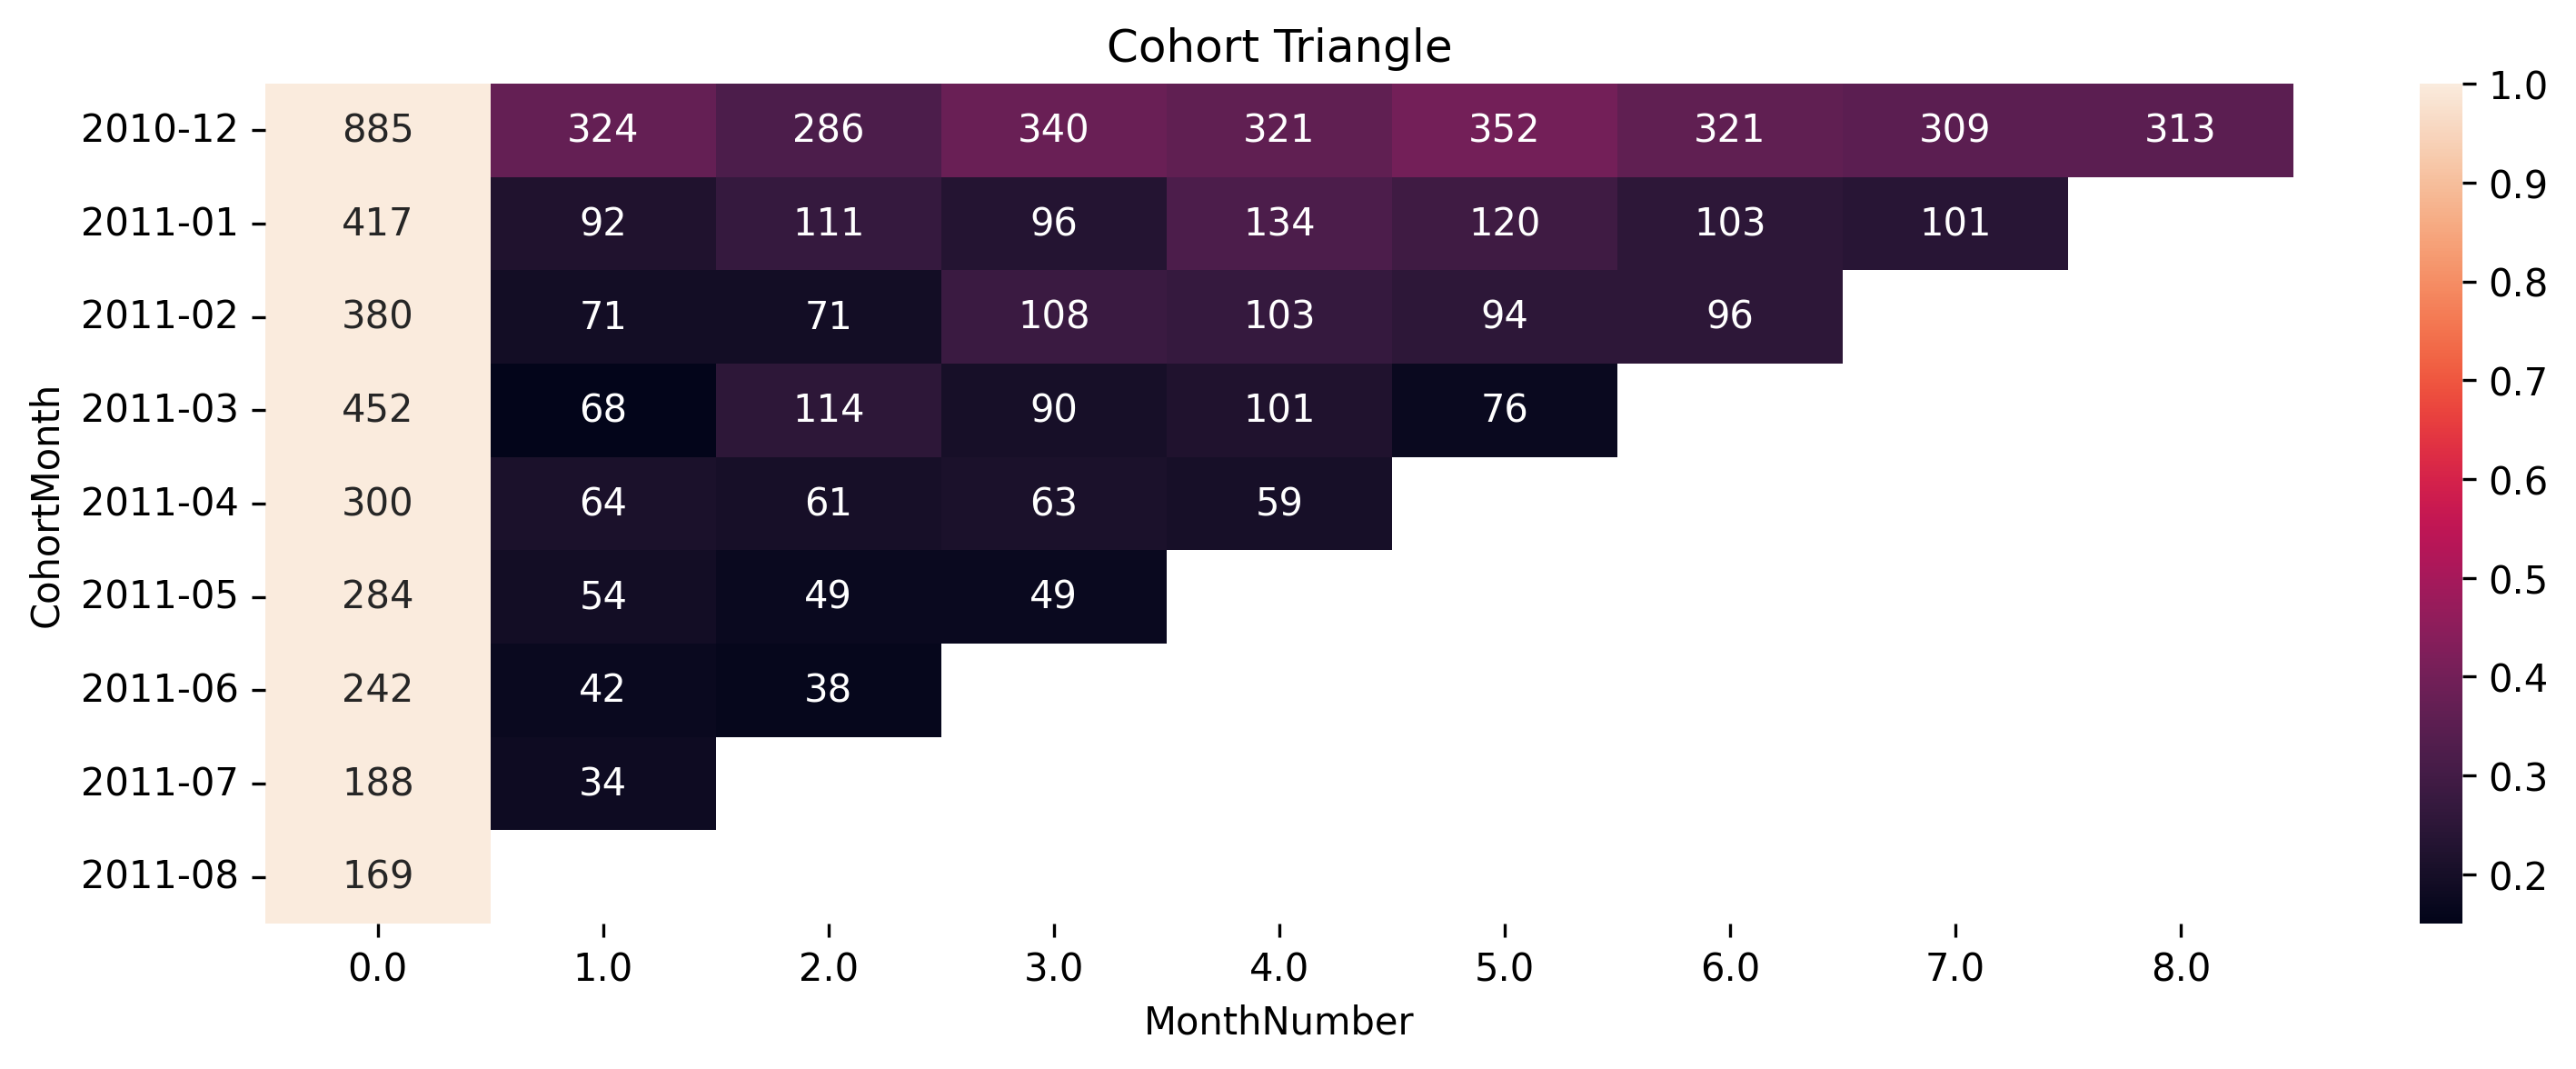

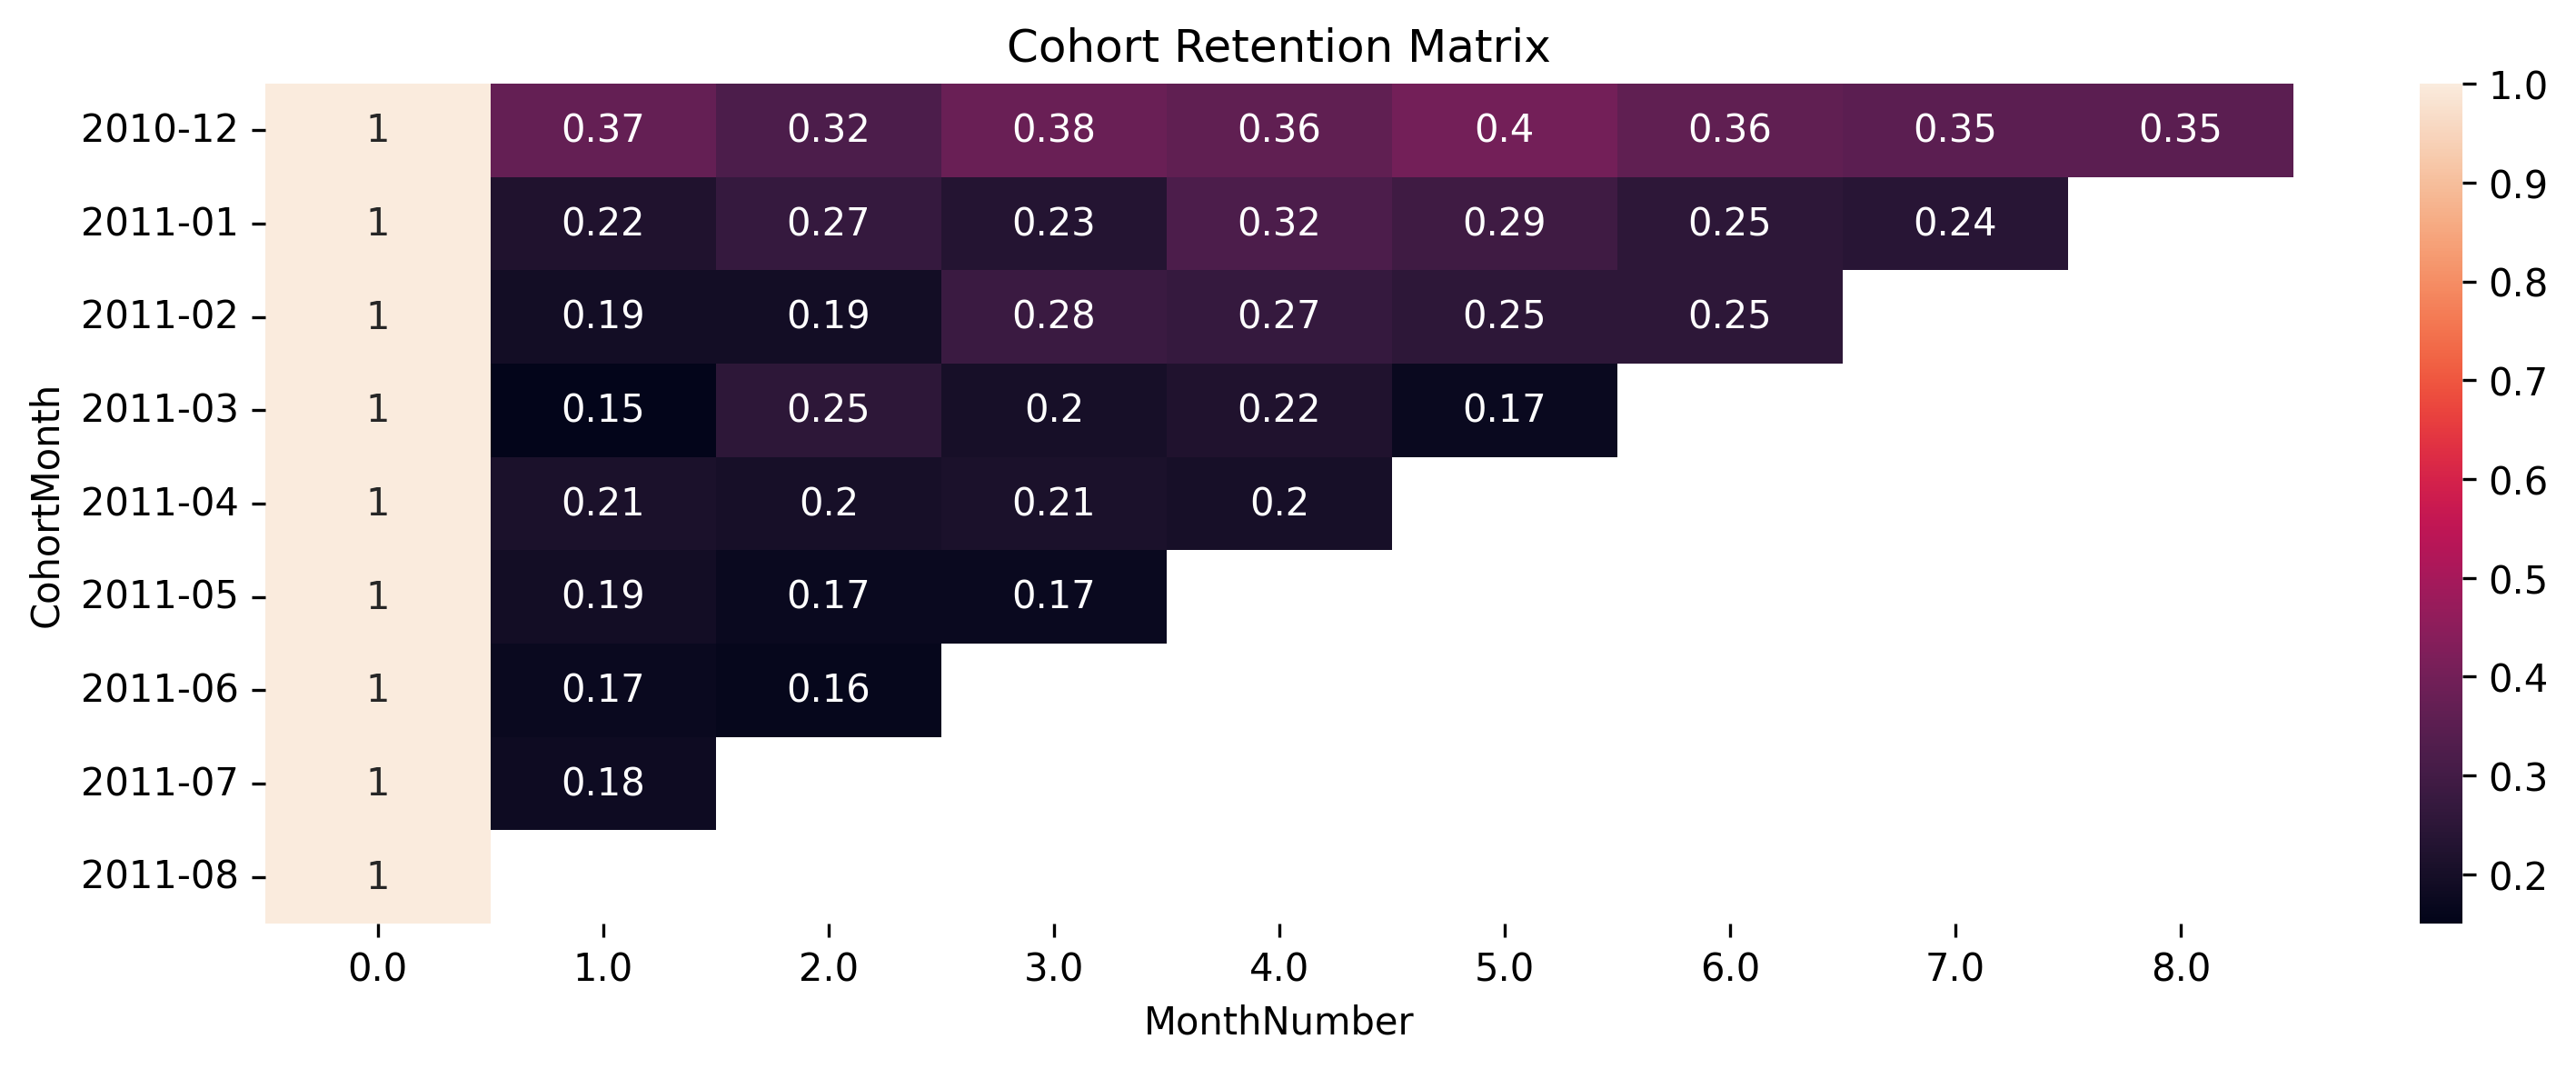

In [85]:
count_pivot = df.pivot_table(index = "CohortMonth", columns = "MonthNumber", values = "NoCustomers")

cohort_size = count_pivot.iloc[:,0]
count_pivot_norm = count_pivot.divide(cohort_size, axis = 0).round(2)

plt.figure(figsize = (12,4), dpi = 300)
sns.heatmap(data = count_pivot_norm, annot = count_pivot, fmt = 'g')
plt.title("Cohort Triangle")
plt.show()

plt.figure(figsize = (12,4), dpi = 300)
sns.heatmap(data = count_pivot_norm, annot = count_pivot_norm, fmt = 'g')
plt.title("Cohort Retention Matrix")
plt.show()

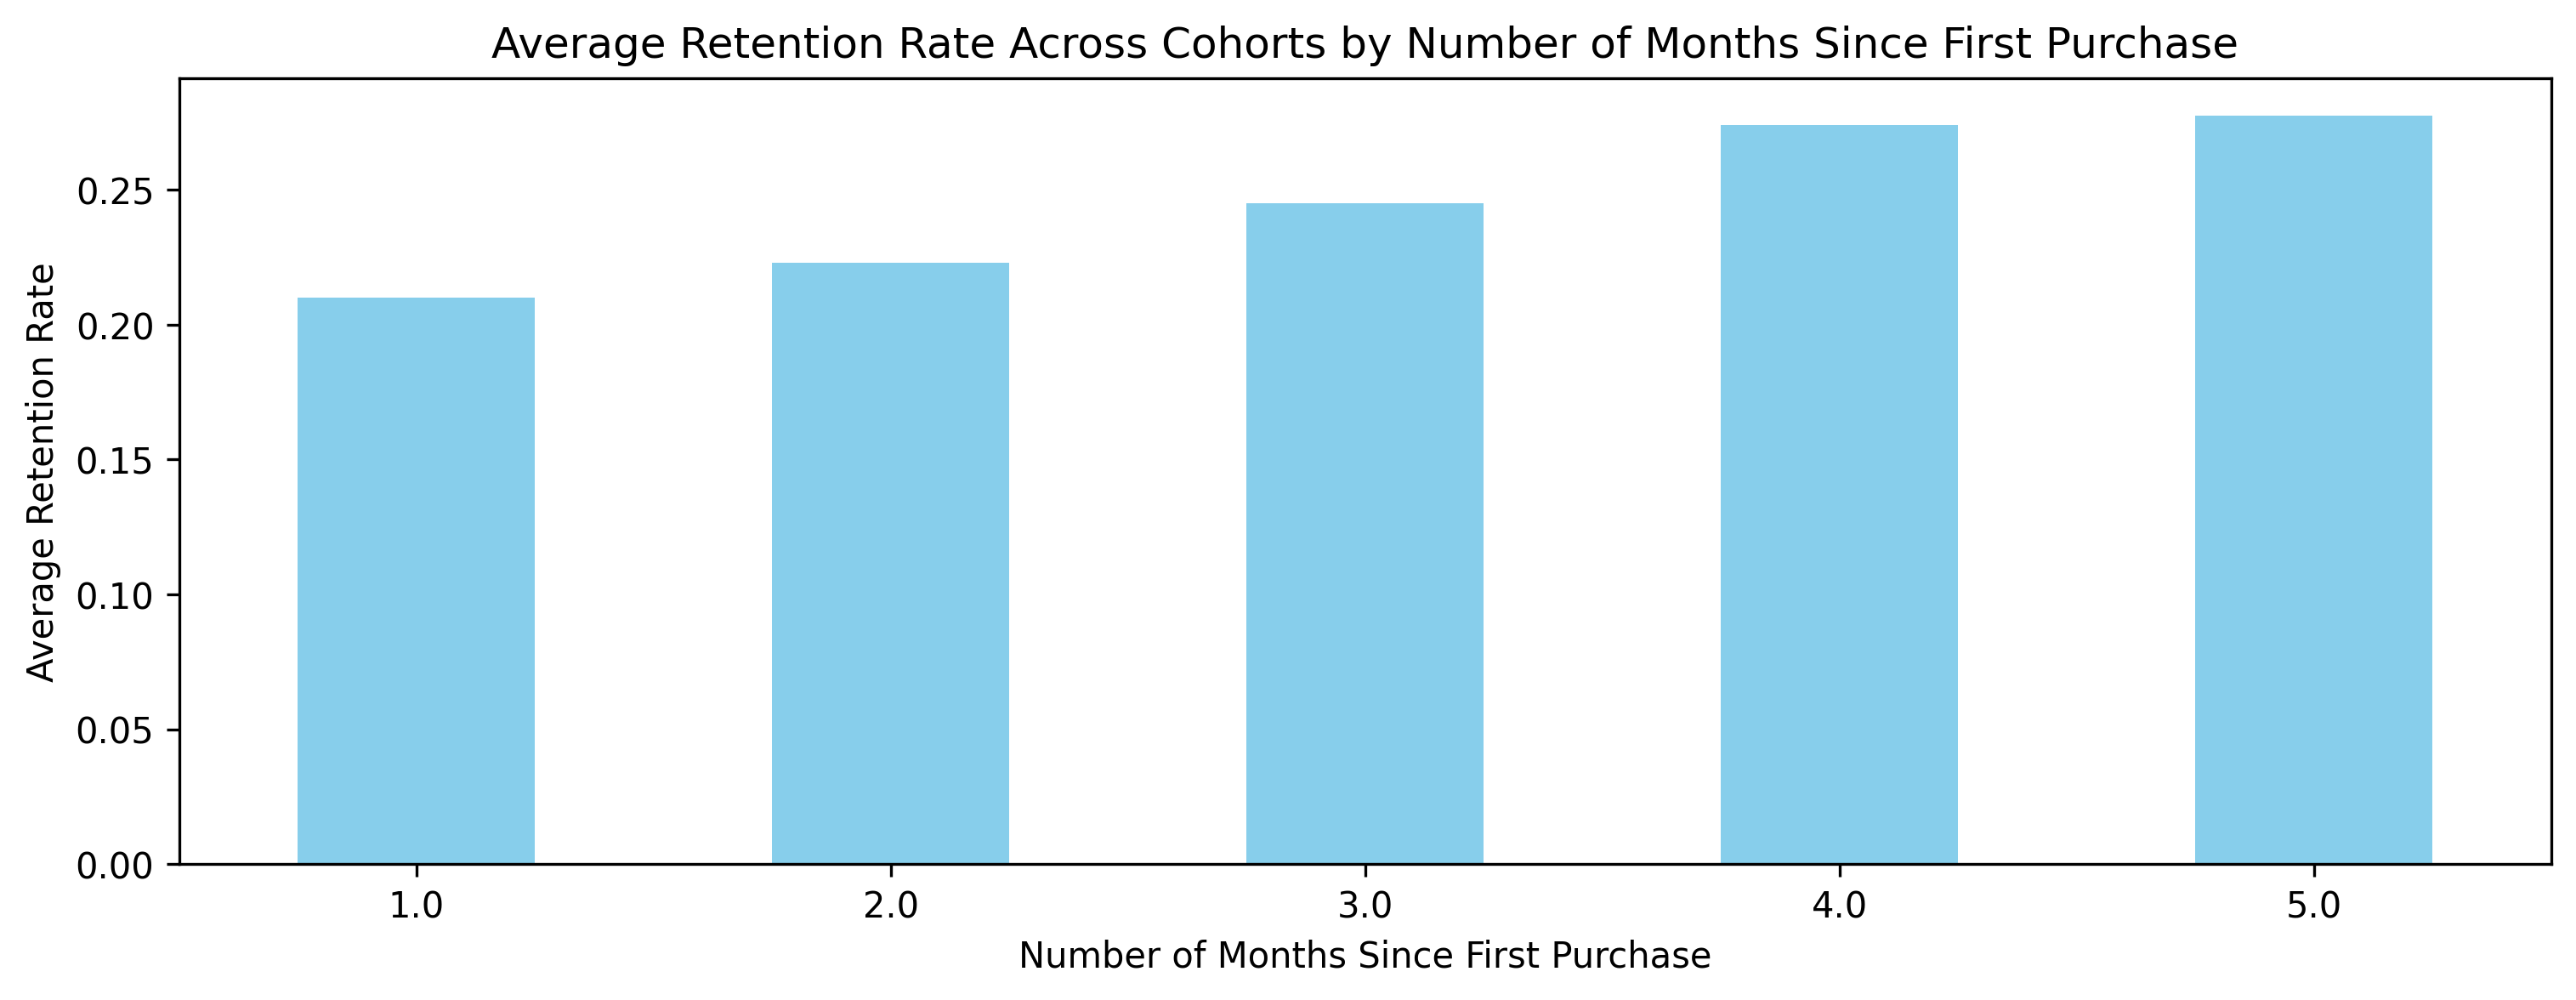

In [89]:
avg_retention = count_pivot_norm.mean(axis = 0)

plt.figure(figsize = (12,4), dpi = 300)
avg_retention[avg_retention.index.isin([1,2,3,4,5])].plot(kind = 'bar', color = 'skyblue')
plt.ylabel("Average Retention Rate")
plt.xlabel("Number of Months Since First Purchase")
plt.title("Average Retention Rate Across Cohorts by Number of Months Since First Purchase")
plt.xticks(rotation = 0)
plt.show()